# Validação do modelo de perda de caminho log-distância

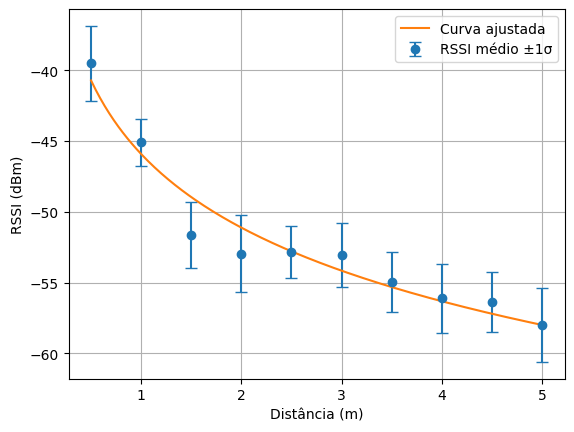

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# Medidas de RSSI para validar modelo de perda de caminho
#Canal 1
medidas_rssi = {
    0.5: [-39,-42,-40,-41,-39,-42,-39,-38,-43,-41,-39,-42,-41,-33,-38,-33,-42,-39,-38,-41],
    1.0: [-46,-50,-44,-43,-46,-46,-45,-43,-46,-45,-44,-43,-43,-46,-46,-46,-46,-46,-43,-45],
    1.5: [-51,-54,-52,-46,-51,-52,-55,-48,-50,-51,-49,-54,-52,-49,-54,-52,-53,-51,-54,-55],
    2.0: [-54,-58,-57,-57,-53,-51,-55,-50,-51,-53,-51,-56,-48,-52,-54,-52,-50,-55,-53,-49],
    2.5: [-52,-53,-53,-54,-53,-52,-54,-52,-53,-52,-50,-56,-51,-55,-51,-57,-50,-51,-53,-55],
    3.0: [-54,-52,-53,-51,-50,-51,-52,-51,-58,-51,-56,-54,-51,-51,-55,-51,-54,-57,-53,-56],
    3.5: [-53,-53,-54,-54,-53,-53,-54,-55,-58,-56,-55,-55,-55,-56,-61,-55,-57,-51,-57,-54],
    4.0: [-53,-54,-59,-55,-52,-59,-56,-53,-59,-58,-56,-57,-53,-56,-54,-59,-56,-57,-61,-55],
    4.5: [-57,-58,-55,-55,-57,-56,-53,-57,-52,-60,-58,-54,-58,-56,-56,-60,-57,-53,-58,-57],
    5.0: [-62,-59,-58,-62,-58,-61,-54,-56,-58,-59,-56,-57,-59,-58,-57,-60,-52,-62,-55,-57]
}

distancias = np.array(list(medidas_rssi.keys()))
medias      = np.array([np.mean(vals) for vals in medidas_rssi.values()])
desvios       = np.array([np.std(vals)  for vals in medidas_rssi.values()])

# --- plot -----------------------------------------------------------

# Regressão linear no modelo log‑distância
log_d = np.log10(distancias)
coef = np.polyfit(log_d, medias, 1)  # coef[0] = slope, coef[1] = intercept

# Curva ajustada
d_fit = np.linspace(distancias.min(), distancias.max(), 200)
rssi_fit = np.polyval(coef, np.log10(d_fit))

# Gráfico com pontos médios, barras de erro e curva ajustada
plt.errorbar(distancias, medias, yerr=desvios, fmt='o', capsize=4,linestyle='none', label='RSSI médio ±1σ')
plt.plot(d_fit, rssi_fit,label=f'Curva ajustada')

plt.xlabel('Distância (m)')
plt.ylabel('RSSI (dBm)')
plt.grid(True)
plt.legend()
plt.savefig("rssi_vs_distancia_ch1.png",dpi=900)
plt.show()


In [121]:
print(medias)
print(desvios)
print('Média: ',np.mean(medias))

# valores previstos pelo modelo
y_pred = np.polyval(coef, np.log10(distancias))

ss_res = np.sum((medias - y_pred) ** 2)           # soma dos erros ao quadrado
ss_tot = np.sum((medias - np.mean(medias)) ** 2)   # variância total
r2      = 1 - ss_res / ss_tot

rmse    = np.sqrt(np.mean((medias - y_pred) ** 2))

print(f"n   = {abs(coef[0])/10:.3f}")
print(f"R²  = {r2:.3f}")
print(f"RMSE = {rmse:.3f} dB")

[-39.5  -45.1  -51.65 -52.95 -52.85 -53.05 -54.95 -56.1  -56.35 -58.  ]
[2.63628527 1.67032931 2.35106359 2.72901081 1.85135086 2.29074224
 2.13248681 2.44744765 2.12779228 2.60768096]
Média:  -52.05
n   = 1.728
R²  = 0.948
RMSE = 1.220 dB


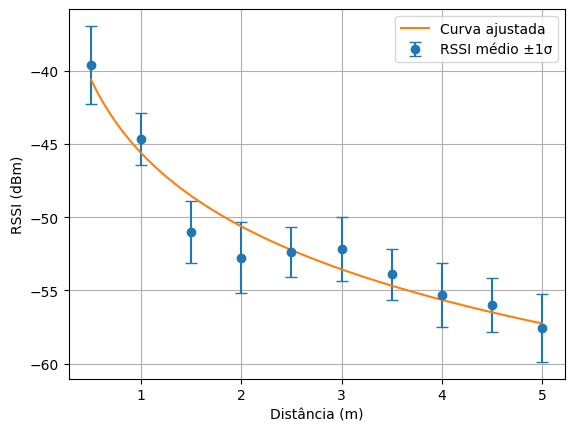

In [122]:
#Canal 6
medidas_rssi = {
    0.5:[-38,-44,-40,-42,-38,-41,-39,-39,-42,-42,-39,-42,-40,-34,-38,-33,-42,-39,-38,-42],
    1.0:[-45,-50,-43,-43,-46,-45,-45,-43,-46,-44,-43,-42,-43,-45,-46,-45,-46,-46,-43,-44],
    1.5:[-50,-54,-51,-47,-50,-52,-54,-48,-50,-50,-48,-53,-51,-48,-53,-51,-52,-51,-53,-54],
    2.0:[-53,-57,-56,-56,-52,-50,-54,-49,-51,-53,-51,-56,-49,-53,-55,-52,-50,-55,-53,-50],
    2.5:[-51,-53,-53,-53,-52,-51,-53,-52,-52,-52,-50,-56,-50,-54,-51,-56,-50,-51,-53,-54],
    3.0:[-53,-52,-53,-50,-49,-50,-52,-50,-56,-50,-55,-53,-50,-50,-54,-50,-53,-56,-52,-55],
    3.5:[-52,-53,-54,-53,-52,-53,-54,-53,-57,-55,-54,-54,-53,-54,-59,-54,-55,-51,-55,-53],
    4.0:[-53,-54,-58,-54,-51,-58,-55,-53,-58,-57,-55,-56,-53,-55,-54,-58,-55,-55,-60,-54],
    4.5:[-56,-58,-55,-55,-57,-56,-54,-57,-52,-60,-57,-55,-57,-55,-55,-59,-56,-53,-57,-56],
    5.0:[-61,-59,-57,-61,-57,-60,-53,-56,-58,-59,-56,-57,-58,-57,-56,-60,-53,-61,-55,-57],
}

distancias = np.array(list(medidas_rssi.keys()))
medias      = np.array([np.mean(vals) for vals in medidas_rssi.values()])
desvios       = np.array([np.std(vals)  for vals in medidas_rssi.values()])

# --- plot -----------------------------------------------------------

# Regressão linear no modelo log‑distância
log_d = np.log10(distancias)
coef = np.polyfit(log_d, medias, 1)  # coef[0] = slope, coef[1] = intercept

# Curva ajustada
d_fit = np.linspace(distancias.min(), distancias.max(), 200)
rssi_fit = np.polyval(coef, np.log10(d_fit))

# Gráfico com pontos médios, barras de erro e curva ajustada
plt.errorbar(distancias, medias, yerr=desvios, fmt='o', capsize=4,linestyle='none', label='RSSI médio ±1σ')
plt.plot(d_fit, rssi_fit,label=f'Curva ajustada')

plt.xlabel('Distância (m)')
plt.ylabel('RSSI (dBm)')
plt.grid(True)
plt.legend()
plt.savefig("rssi_vs_distancia_ch6.png",dpi=900)
plt.show()

In [123]:
print(medias)
print(desvios)
print('Média: ',np.mean(medias))
# valores previstos pelo modelo
y_pred = np.polyval(coef, np.log10(distancias))

ss_res = np.sum((medias - y_pred) ** 2)           # soma dos erros ao quadrado
ss_tot = np.sum((medias - np.mean(medias)) ** 2)   # variância total
r2      = 1 - ss_res / ss_tot

rmse    = np.sqrt(np.mean((medias - y_pred) ** 2))

print(f"n   = {abs(coef[0])/10:.3f}")
print(f"R²  = {r2:.3f}")
print(f"RMSE = {rmse:.3f} dB")

[-39.6  -44.65 -51.   -52.75 -52.35 -52.15 -53.9  -55.3  -56.   -57.55]
[2.67207784 1.76847392 2.0976177  2.44693686 1.71099386 2.17428149
 1.72916165 2.19317122 1.84390889 2.333988  ]
Média:  -51.525
n   = 1.666
R²  = 0.942
RMSE = 1.245 dB


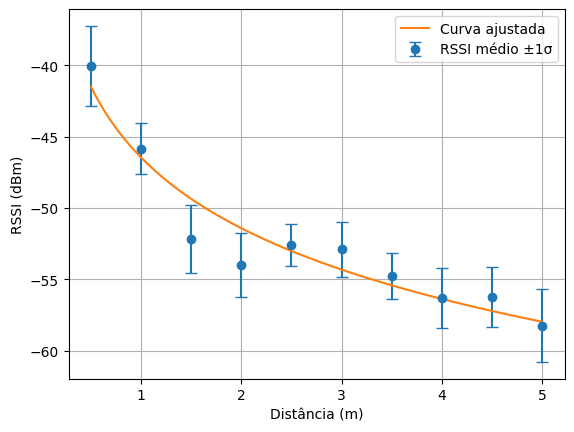

In [124]:
#Canal 11
medidas_rssi = {
    0.5:[-40,-43,-39,-41,-39,-43,-40,-38,-44,-42,-38,-43,-42,-33,-39,-34,-43,-40,-39,-41],
    1.0:[-47,-51,-45,-44,-47,-47,-46,-44,-47,-45,-44,-43,-44,-47,-47,-46,-47,-47,-44,-45],
    1.5:[-52,-55,-50,-48,-52,-53,-55,-49,-51,-50,-49,-55,-52,-49,-55,-52,-53,-52,-55,-56],
    2.0:[-55,-59,-54,-53,-56,-54,-55,-50,-53,-55,-53,-57,-50,-54,-56,-53,-51,-56,-54,-52],
    2.5:[-53,-54,-52,-53,-53,-52,-54,-52,-53,-52,-50,-55,-50,-54,-52,-55,-50,-51,-53,-54],
    3.0:[-55,-53,-54,-51,-50,-51,-53,-51,-57,-51,-55,-53,-51,-51,-55,-52,-53,-56,-52,-54],
    3.5:[-54,-54,-55,-54,-53,-53,-55,-53,-58,-56,-55,-55,-54,-55,-59,-55,-56,-52,-55,-54],
    4.0:[-54,-55,-59,-55,-52,-59,-56,-54,-59,-58,-56,-57,-54,-56,-55,-59,-56,-57,-60,-55],
    4.5:[-57,-58,-55,-55,-57,-56,-53,-57,-52,-60,-58,-55,-57,-55,-55,-60,-57,-53,-58,-57],
    5.0:[-62,-59,-58,-62,-58,-61,-54,-57,-59,-60,-57,-56,-59,-58,-57,-61,-53,-62,-55,-57],
}

distancias = np.array(list(medidas_rssi.keys()))
medias      = np.array([np.mean(vals) for vals in medidas_rssi.values()])
desvios       = np.array([np.std(vals)  for vals in medidas_rssi.values()])

# --- plot -----------------------------------------------------------

# Regressão linear no modelo log‑distância
log_d = np.log10(distancias)
coef = np.polyfit(log_d, medias, 1)  # coef[0] = slope, coef[1] = intercept

# Curva ajustada
d_fit = np.linspace(distancias.min(), distancias.max(), 200)
rssi_fit = np.polyval(coef, np.log10(d_fit))

# Gráfico com pontos médios, barras de erro e curva ajustada
plt.errorbar(distancias, medias, yerr=desvios, fmt='o', capsize=4,linestyle='none', label='RSSI médio ±1σ')
plt.plot(d_fit, rssi_fit,label=f'Curva ajustada')

plt.xlabel('Distância (m)')
plt.ylabel('RSSI (dBm)')
plt.grid(True)
plt.legend()
plt.savefig("rssi_vs_distancia_ch11.png",dpi=900)
plt.show()

In [125]:
print(medias)
print(desvios)
print('Média: ',np.mean(medias))
# valores previstos pelo modelo
y_pred = np.polyval(coef, np.log10(distancias))

ss_res = np.sum((medias - y_pred) ** 2)           # soma dos erros ao quadrado
ss_tot = np.sum((medias - np.mean(medias)) ** 2)   # variância total
r2      = 1 - ss_res / ss_tot

rmse    = np.sqrt(np.mean((medias - y_pred) ** 2))

print(f"n   = {abs(coef[0])/10:.3f}")
print(f"R²  = {r2:.3f}")
print(f"RMSE = {rmse:.3f} dB")

[-40.05 -45.85 -52.15 -54.   -52.6  -52.9  -54.75 -56.3  -56.25 -58.25]
[2.81913107 1.79652442 2.39321959 2.21359436 1.49666295 1.92093727
 1.60857079 2.1        2.09463601 2.54705713]
Média:  -52.31
n   = 1.647
R²  = 0.923
RMSE = 1.435 dB


# Definição do limiar de RSSI

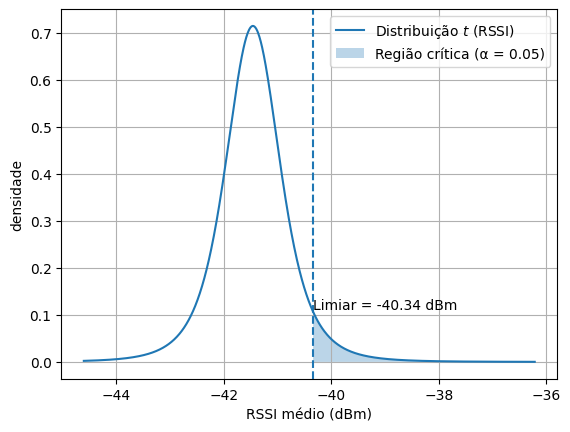

In [52]:
from scipy.stats import t

medidas_0_5m = {
    'Iphone16': [-39, -42, -40, -41, -39, -42, -39, -38, -43, -41, -39, -42, -41, -33, -38, -33, -42, -39, -38, -41],
    'Iphone11': [-39, -53, -35, -38, -46, -37, -40, -44, -39, -38,-36, -41, -40, -53, -54, -34, -47, -34, -50, -49],
    'GalaxyS21': [-38, -47, -45, -50, -45, -41, -39, -31, -44, -46,-52, -28, -37, -53, -29, -54, -31, -48, -44, -41],
    'GalaxyJ7': [-33, -46, -45, -43, -49, -41, -41, -41, -43, -51,-43, -47, -37, -38, -35, -33, -45, -41, -36, -37],
    'MotoE7': [-42, -46, -54, -45, -37, -37, -50, -35, -23, -46,-37, -34, -52, -32, -55, -45, -43, -33, -41, -54],
}

# ------------------------------------------------------------------
# estatística de interesse: média de RSSI de cada dispositivo
means = np.array([np.mean(v) for v in medidas_0_5m.values()])

# parâmetros da distribuição t
df     = len(means) - 1        # graus de liberdade = 4
alpha  = 0.05                  # 95% unilateral à direita
m_bar  = means.mean()                 # média global
s      = np.std(means, ddof=1)        # desvio‑padrão das médias
se     = s / np.sqrt(df+1)               # erro‑padrão
t_crit = t.ppf(1 - alpha, df)         # limiar crítico (escala t)

# ----- curva em escala RSSI --------------------------------------
x_t      = np.linspace(-6, 10, 1000)        # eixo em unidades t
x_rssi   = m_bar + x_t * se                 # transforma para dBm
pdf_rssi = t.pdf(x_t, df) / se              # ajusta densidade

rssi_crit = m_bar + t_crit * se             # limiar crítico em dBm

plt.plot(x_rssi, pdf_rssi, label=r'Distribuição $t$ (RSSI)')
plt.fill_between(x_rssi[x_rssi >= rssi_crit],
                 pdf_rssi[x_rssi >= rssi_crit],
                 alpha=0.3, label=f'Região crítica (α = {alpha:.2f})')
plt.axvline(rssi_crit, linestyle='--')
plt.text(rssi_crit, t.pdf(t_crit, df)/se * 1.05,
         f'Limiar = {rssi_crit:.2f} dBm', ha='left')

plt.xlabel('RSSI médio (dBm)')
plt.ylabel('densidade')
plt.grid(True)
plt.legend()
plt.savefig("limiar.png",dpi=900)
plt.show()